# ML Lab 03 (Final) – Clustering, ANN Regression/Classification, Bi-LSTM
| Bài | Bài toán | Dữ liệu | Mô hình | Chỉ số |
|---|---|---|---|---|
| 1 | Clustering | `wine-clustering.csv` | StandardScaler → K-Means (+ PCA để so sánh, trực quan hóa) | Silhouette |
| 2 | Regression | `50_Startups.csv` (target `Profit`) | ANN 64-32-16-1 (Keras) | MSE, RMSE |
| 3 | Classification | `Dry_Bean_Dataset.xlsx` (target `Class`) | MLPClassifier (100, 50) | F1, Confusion Matrix |
| 4 | Sentiment | `Reviews_dataset.csv` | TextVectorization → Embedding → Bi-LSTM | F1, Confusion Matrix |

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "data")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)
SEED = 42


def save_show(name):
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, name), dpi=110, bbox_inches="tight")
    plt.show()


def write_report(name, text):
    with open(os.path.join(OUTPUT_DIR, name), "w", encoding="utf-8") as f:
        f.write(text)
    print(f"Đã lưu outputs/{name}")

---
## Bài 1 – Phân cụm Wine (K-Means)
### 1.1. Thang đo các feature – có cần chuẩn hóa?

In [2]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

wine = pd.read_csv(os.path.join(DATA_DIR, "wine-clustering.csv"))
print(f"Wine: {wine.shape}, giá trị thiếu: {wine.isna().sum().sum()}")
wine.describe().T[["mean", "std", "min", "max"]].sort_values("std", ascending=False).round(2)

Wine: (178, 13), giá trị thiếu: 0


,mean,std,min,max
Proline,746.89,314.91,278.00,1680.00
Magnesium,99.74,14.28,70.00,162.00
Ash_Alcanity,19.49,3.34,10.60,30.00
Color_Intensity,5.06,2.32,1.28,13.00
Malic_Acid,2.34,1.12,0.74,5.80
Flavanoids,2.03,1.00,0.34,5.08
Alcohol,13.00,0.81,11.03,14.83
OD280,2.61,0.71,1.27,4.00
Total_Phenols,2.30,0.63,0.98,3.88
Proanthocyanins,1.59,0.57,0.41,3.58


In [3]:
def kmeans(X, k):
    return KMeans(n_clusters=k, random_state=SEED, n_init=20).fit(X)


# Thử K-Means (K = 3, chỉ để minh họa) trên dữ liệu THÔ, rồi so với 2 cách phân cụm khác bằng Adjusted Rand Index
# ARI = 1: hai cách chia cụm trùng khớp hoàn toàn · ARI ≈ 0: không liên quan gì nhau
X_wine = StandardScaler().fit_transform(wine)
labels_raw = kmeans(wine, 3).labels_
pd.DataFrame({"ARI so với K-Means trên dữ liệu thô": [
    adjusted_rand_score(labels_raw, kmeans(wine[["Proline"]], 3).labels_),
    adjusted_rand_score(labels_raw, kmeans(X_wine, 3).labels_),
]}, index=["K-Means chỉ dùng mỗi Proline", "K-Means trên 13 feature đã chuẩn hóa"]).round(4)

,ARI so với K-Means trên dữ liệu thô
K-Means chỉ dùng mỗi Proline,1.0000
K-Means trên 13 feature đã chuẩn hóa,0.3543


**Nhận xét:**
- `Proline` có std ~315, lớn hơn feature lớn thứ hai (`Magnesium`, std ~14) khoảng 22 lần và lớn hơn `Nonflavanoid_Phenols` (std ~0.12) hơn 2 600 lần.
- K-Means trên dữ liệu thô cho kết quả **trùng khớp hoàn toàn** với K-Means chỉ dùng mỗi `Proline` (ARI = 1.0): 12 feature còn lại không đóng góp gì. Sau khi chuẩn hóa, cách chia cụm khác hẳn (ARI chỉ 0.35).

→ K-Means dùng khoảng cách Euclid nên bị feature có thang đo lớn chi phối. **Bắt buộc chuẩn hóa** (`StandardScaler`) trước khi phân cụm.

### 1.2. Chọn K bằng Elbow & Silhouette (trên 13 feature đã chuẩn hóa)

K tối ưu = 3


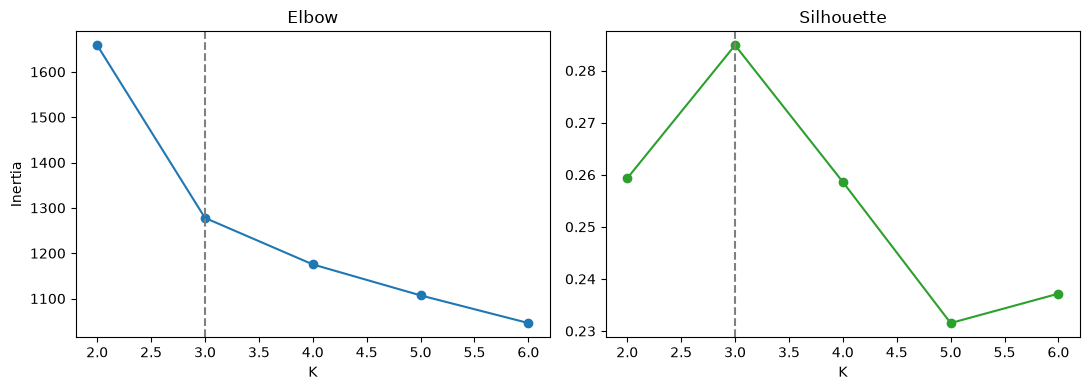

,Inertia,Inertia giảm,Silhouette
K,,,
2,1658.7589,NaN,0.2593
3,1277.9285,380.8304,0.2849
4,1175.3519,102.5766,0.2586
5,1107.0073,68.3445,0.2315
6,1046.0023,61.0050,0.2372


In [4]:
K_RANGE = list(range(2, 7))
fits = {k: kmeans(X_wine, k) for k in K_RANGE}
choose_k = pd.DataFrame({"Inertia": [fits[k].inertia_ for k in K_RANGE],
                         "Silhouette": [silhouette_score(X_wine, fits[k].labels_) for k in K_RANGE]}, index=K_RANGE)
choose_k.insert(1, "Inertia giảm", -choose_k["Inertia"].diff())
choose_k.index.name = "K"
K_OPT = int(choose_k["Silhouette"].idxmax())
print(f"K tối ưu = {K_OPT}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(K_RANGE, choose_k["Inertia"], "o-"); axes[0].set(title="Elbow", xlabel="K", ylabel="Inertia")
axes[1].plot(K_RANGE, choose_k["Silhouette"], "o-", color="tab:green"); axes[1].set(title="Silhouette", xlabel="K")
for ax in axes:
    ax.axvline(K_OPT, ls="--", color="gray")
save_show("ex1_choose_k.png")
choose_k.round(4)

**Nhận xét:** inertia giảm mạnh khi đi từ K = 2 lên K = 3 (−381), sau đó chỉ còn giảm −103, −68, −61 → "khuỷu" nằm ở **K = 3**. Silhouette cũng đạt cực đại tại K = 3 (0.2849). Hai tiêu chí cùng chỉ ra **K = 3**.

### 1.3. PCA có làm cụm tốt hơn không?
Phân cụm trong không gian PCA rồi tính Silhouette theo **hai cách**: trên cùng 13 chiều đã chuẩn hóa (so sánh được với dữ liệu gốc) và ngay trong không gian PCA.

In [5]:
rows = [{"Không gian phân cụm": "13 feature gốc", "Variance giữ lại": 1.0,
         "Silhouette (đo trên 13 chiều)": choose_k.loc[K_OPT, "Silhouette"],
         "Silhouette (đo trong không gian phân cụm)": choose_k.loc[K_OPT, "Silhouette"]}]
for n in range(2, 7):
    pca = PCA(n_components=n, random_state=SEED)
    Z = pca.fit_transform(X_wine)
    labels = kmeans(Z, K_OPT).labels_
    rows.append({"Không gian phân cụm": f"PCA {n} chiều", "Variance giữ lại": pca.explained_variance_ratio_.sum(),
                 "Silhouette (đo trên 13 chiều)": silhouette_score(X_wine, labels),
                 "Silhouette (đo trong không gian phân cụm)": silhouette_score(Z, labels)})
pca_table = pd.DataFrame(rows).set_index("Không gian phân cụm")
pca_table.round(4)

,Variance giữ lại,Silhouette (đo trên 13 chiều),Silhouette (đo trong không gian phân cụm)
Không gian phân cụm,,,
13 feature gốc,1.0000,0.2849,0.2849
PCA 2 chiều,0.5541,0.2831,0.5611
PCA 3 chiều,0.6653,0.2840,0.4532
PCA 4 chiều,0.7360,0.2819,0.4066
PCA 5 chiều,0.8016,0.2849,0.3691
PCA 6 chiều,0.8510,0.2849,0.3463


**Nhận xét:**
- Đo trên cùng 13 chiều, mọi cấu hình PCA cho Silhouette 0.2819 – 0.2849, **không cao hơn** dữ liệu gốc (0.2849).
- Đo ngay trong không gian PCA thì số tăng dần khi số chiều giảm (6 chiều 0.3463 → 2 chiều 0.5611). Con số 0.5611 cao chỉ vì khoảng cách được tính trên ít chiều hơn, nên không dùng nó để kết luận PCA tốt hơn.

→ Mô hình cuối: **K-Means K = 3 trên 13 feature**; PCA 2D (giữ 55.4 % variance) chỉ dùng để vẽ.
### 1.4. Mô hình cuối

Silhouette: 0.2849 · Kích thước cụm: {0: 65, 1: 51, 2: 62}


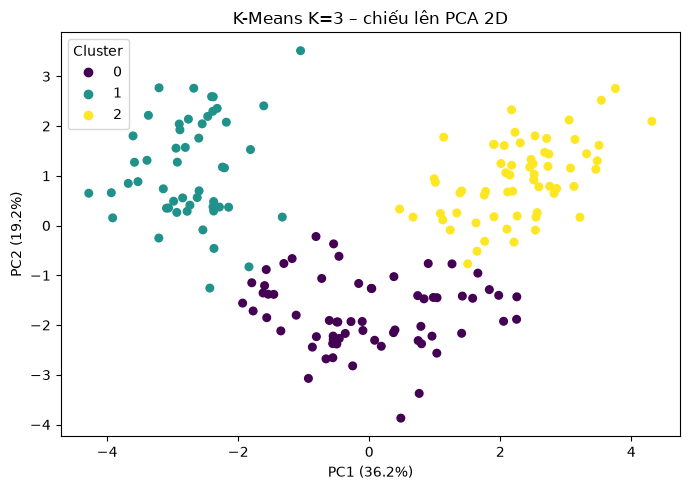

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
Cluster,,,,,,,,,,,,,
0,12.25,1.90,2.23,20.06,92.74,2.25,2.05,0.36,1.62,2.97,1.06,2.80,510.17
1,13.13,3.31,2.42,21.24,98.67,1.68,0.82,0.45,1.15,7.23,0.69,1.70,619.06
2,13.68,2.00,2.47,17.46,107.97,2.85,3.00,0.29,1.92,5.45,1.07,3.16,1100.23


In [6]:
final = kmeans(X_wine, K_OPT)
wine_score = silhouette_score(X_wine, final.labels_)
centers = wine.assign(Cluster=final.labels_).groupby("Cluster").mean()
sizes = pd.Series(final.labels_).value_counts().sort_index()
print(f"Silhouette: {wine_score:.4f} · Kích thước cụm: {sizes.to_dict()}")

pca2 = PCA(n_components=2, random_state=SEED)
Z2 = pca2.fit_transform(X_wine)
plt.figure(figsize=(7, 5))
sc = plt.scatter(Z2[:, 0], Z2[:, 1], c=final.labels_, cmap="viridis", s=30)
plt.legend(*sc.legend_elements(), title="Cluster")
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})"); plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")
plt.title(f"K-Means K={K_OPT} – chiếu lên PCA 2D")
save_show("ex1_clusters_pca2d.png")
centers.round(2)

**Đọc tâm cụm (giá trị gốc):**
- Cụm 2 (62 mẫu): `Proline` cao nhất (~1 100), `Flavanoids` cao nhất (3.00), `Alcohol` cao nhất (13.68).
- Cụm 1 (51 mẫu): `Color_Intensity` cao nhất (7.23), `Hue` thấp nhất (0.69), `Flavanoids` thấp nhất (0.82).
- Cụm 0 (65 mẫu): `Proline` thấp nhất (~510), màu nhạt nhất (`Color_Intensity` 2.97), `Alcohol` thấp nhất (12.25).

Silhouette 0.2849 là mức trung bình: các cụm có tách nhau nhưng vùng ranh giới còn chồng lấn (thấy rõ trên hình PCA 2D).

In [7]:
write_report("ex1_wine_clustering_report.md",
             "# Bài 1 – Wine Clustering (K-Means)\n\n## Chọn K (13 feature đã chuẩn hóa)\n\n"
             + choose_k.to_markdown(floatfmt=".4f") + f"\n\n→ **K tối ưu = {K_OPT}**\n\n![Chọn K](ex1_choose_k.png)\n\n"
             + f"## PCA có giúp phân cụm tốt hơn? (K = {K_OPT})\n\n" + pca_table.to_markdown(floatfmt=".4f")
             + f"\n\n## Mô hình cuối\n\n- Silhouette: **{wine_score:.4f}**\n- Kích thước cụm: {sizes.to_dict()}\n\n"
             + "Tâm cụm (giá trị gốc):\n\n" + centers.to_markdown(floatfmt=".2f") + "\n\n![Clusters](ex1_clusters_pca2d.png)\n")

Đã lưu outputs/ex1_wine_clustering_report.md


---
## Bài 2 – Hồi quy Profit bằng ANN (Keras)
### 2.1. Khảo sát dữ liệu

In [8]:
startups = pd.read_csv(os.path.join(DATA_DIR, "50_Startups.csv"))
print("Giá trị thiếu:", startups.isna().sum().to_dict())
print("Tương quan với Profit:", startups.drop(columns="State").corr()["Profit"].drop("Profit").round(3).to_dict())
startups.describe().T[["mean", "std", "min", "max"]].round(1)

Giá trị thiếu: {'R&D Spend': 2, 'Administration': 3, 'Marketing Spend': 2, 'State': 0, 'Profit': 0}
Tương quan với Profit: {'R&D Spend': 0.971, 'Administration': 0.158, 'Marketing Spend': 0.742}


,mean,std,min,max
R&D Spend,72084.9,44984.6,0.0,165349.2
Administration,123179.9,27414.9,51283.1,182645.6
Marketing Spend,214887.4,122142.2,0.0,471784.1
Profit,112012.6,40306.2,14681.4,192261.8


**Nhận xét:**
- Có 7 giá trị thiếu ở 3 cột chi phí → cần điền (median, fit trên train).
- Các cột tiền tệ có thang đo khác nhau (std từ ~27 000 tới ~122 000) → chuẩn hóa X.
- Bản thân target `Profit` cũng rất lớn (mean ~112 000, std ~40 000).
- `R&D Spend` tương quan rất mạnh với `Profit` (0.971), `Marketing Spend` khá mạnh (0.742) → quan hệ gần tuyến tính, nên cần so sánh ANN với baseline Linear Regression.

### 2.2. Huấn luyện ANN
- Điền thiếu (median) + chuẩn hóa X + one-hot `State` (`drop_first`), fit trên train.
- Chuẩn hóa cả target `Profit` (lý do: xem thí nghiệm đối chứng ở 2.3).
- EarlyStopping trên validation tách từ train; so sánh với baseline Linear Regression.

In [9]:
import tensorflow as tf  # trên Windows sẽ in cảnh báo "không hỗ trợ GPU" – vô hại, chạy bằng CPU
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential

tf.config.experimental.enable_op_determinism()  # cùng seed → cùng kết quả mỗi lần chạy

NUM_COLS = ["R&D Spend", "Administration", "Marketing Spend"]
X_st = startups[NUM_COLS + ["State"]]
y_st = startups["Profit"].to_numpy().reshape(-1, 1)
X_tr, X_te, y_tr, y_te = train_test_split(X_st, y_st, test_size=0.2, random_state=SEED)

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), NUM_COLS),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), ["State"]),
])
X_tr_p = preprocess.fit_transform(X_tr)
X_te_p = preprocess.transform(X_te)
y_scaler = StandardScaler().fit(y_tr)



def train_ann(y_fit):
    tf.keras.utils.set_random_seed(SEED)
    model = Sequential([Input(shape=(X_tr_p.shape[1],)), Dense(64, activation="relu"),
                        Dense(32, activation="relu"), Dense(16, activation="relu"), Dense(1)])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    hist = model.fit(X_tr_p, y_fit, epochs=500, batch_size=8, validation_split=0.2, verbose=0,
                     callbacks=[EarlyStopping(monitor="val_loss", patience=30, restore_best_weights=True)])
    return model, hist


ann_reg, hist_reg = train_ann(y_scaler.transform(y_tr))

y_pred_st = y_scaler.inverse_transform(ann_reg.predict(X_te_p, verbose=0))
mse_ann = mean_squared_error(y_te, y_pred_st)
mse_lr = mean_squared_error(y_te, LinearRegression().fit(X_tr_p, y_tr).predict(X_te_p))
reg_table = pd.DataFrame({"MSE": [mse_ann, mse_lr], "RMSE": np.sqrt([mse_ann, mse_lr])},
                         index=["ANN 64-32-16-1", "Linear Regression (baseline)"])
print(f"Epoch đã chạy: {len(hist_reg.history['loss'])}/500")
reg_table.map(lambda v: f"{v:,.2f}")

Epoch đã chạy: 44/500


,MSE,RMSE
ANN 64-32-16-1,"165,244,432.69","12,854.74"
Linear Regression (baseline),"215,844,329.96","14,691.64"


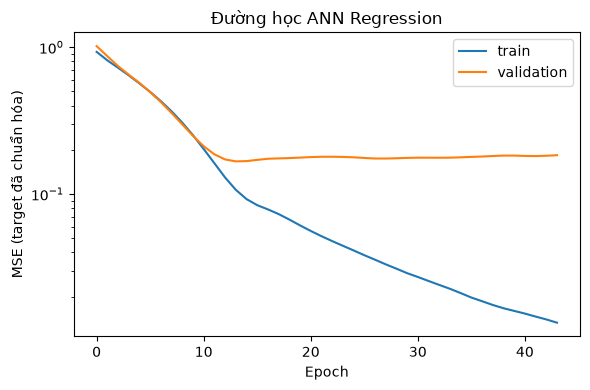

Đã lưu outputs/ex2_ann_regression_result.md


In [10]:
plt.figure(figsize=(6, 4))
plt.plot(hist_reg.history["loss"], label="train"); plt.plot(hist_reg.history["val_loss"], label="validation")
plt.yscale("log"); plt.xlabel("Epoch"); plt.ylabel("MSE (target đã chuẩn hóa)"); plt.title("Đường học ANN Regression")
plt.legend()
save_show("ex2_learning_curve.png")
write_report("ex2_ann_regression_result.md",
             "# Bài 2 – ANN Regression (50_Startups, target = Profit)\n\n" + reg_table.to_markdown(floatfmt=",.2f")
             + f"\n\n- Seed: {SEED} · Epoch đã chạy: {len(hist_reg.history['loss'])}/500 (EarlyStopping patience 30)\n")

**Nhận xét:** ANN đạt RMSE 12 854.74, thấp hơn Linear Regression (14 691.64) khoảng 12.5 %. EarlyStopping dừng ở epoch 44/500.
⚠️ Tập test chỉ có 10 mẫu, nên mức chênh này có thể đổi chiều với cách chia khác. Dữ liệu gần tuyến tính (tương quan R&D – Profit 0.971) nên Linear Regression vẫn là lựa chọn hợp lý vì đơn giản, dễ giải thích.

### 2.3. Đối chứng: nếu không chuẩn hóa target thì sao?
Cùng mạng, cùng seed, cùng dữ liệu – chỉ khác là học thẳng trên `Profit` gốc. Thêm mốc "đoán hằng số = trung bình Profit của train" để biết mô hình có học được gì không.

In [11]:
ann_raw, hist_raw = train_ann(y_tr)
rmse_raw = np.sqrt(mean_squared_error(y_te, ann_raw.predict(X_te_p, verbose=0)))
rmse_const = np.sqrt(mean_squared_error(y_te, np.full(y_te.shape, y_tr.mean())))
print(f"Epoch đã chạy (target để nguyên): {len(hist_raw.history['loss'])}/500")
pd.DataFrame({"RMSE (test)": [np.sqrt(mse_ann), rmse_raw, rmse_const]},
             index=["ANN – target đã chuẩn hóa", "ANN – target để nguyên", "Đoán hằng số = mean(Profit train)"]
             ).map(lambda v: f"{v:,.2f}")

Epoch đã chạy (target để nguyên): 311/500


,RMSE (test)
ANN – target đã chuẩn hóa,"12,854.74"
ANN – target để nguyên,"34,072.55"
Đoán hằng số = mean(Profit train),"33,776.69"


**Nhận xét:** để nguyên target thì mạng chạy tới 311 epoch mà RMSE vẫn là 34 072.55, **ngang (thậm chí tệ hơn) việc đoán hằng số** bằng trung bình (33 776.69): mạng gần như không học được gì. Lý do: output khởi tạo quanh 0 trong khi Profit ~112 000, với learning rate 0.001 trọng số phải dịch chuyển rất xa, và loss MSE (~10¹⁰) quá lớn khiến việc tối ưu kém ổn định.

→ Chuẩn hóa target (rồi `inverse_transform` khi đánh giá) giúp RMSE giảm từ ~34 000 xuống ~12 855.

---
## Bài 3 – Phân loại Dry Bean bằng MLP
Dùng cùng 8 feature và cùng cách chia (test 20 %, stratified, seed 42) như ML Lab02 để so với KNN – mô hình tốt nhất ở Lab02 (F1 weighted **0.9030**, theo `Lab02-Classification-DryBean/outputs/models_performance_report.md`).

Phân bố lớp: {'DERMASON': 3546, 'SIRA': 2636, 'SEKER': 2027, 'HOROZ': 1928, 'CALI': 1630, 'BARBUNYA': 1322, 'BOMBAY': 522}


F1 (weighted): 0.9019 · Số vòng lặp: 43/300 (early stopping)


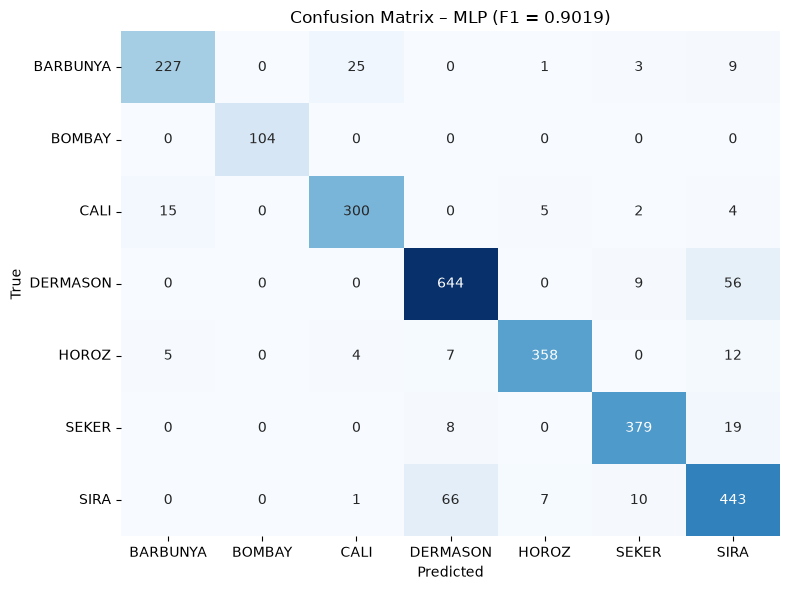

Đã lưu outputs/ex3_ann_classification_report.md


In [12]:
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder

bean = pd.read_excel(os.path.join(DATA_DIR, "Dry_Bean_Dataset.xlsx"))
BEAN_FEATURES = ["Area", "Perimeter", "MajorAxisLength", "MinorAxisLength",
                 "AspectRation", "Eccentricity", "ConvexArea", "EquivDiameter"]
le = LabelEncoder()
y_bean = le.fit_transform(bean["Class"])
print("Phân bố lớp:", bean["Class"].value_counts().to_dict())
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(bean[BEAN_FEATURES], y_bean, test_size=0.2,
                                              random_state=SEED, stratify=y_bean)
scaler_bean = StandardScaler().fit(Xb_tr)  # fit trên train

mlp = MLPClassifier(hidden_layer_sizes=(100, 50), activation="relu", solver="adam", max_iter=300,
                    random_state=SEED, early_stopping=True)
mlp.fit(scaler_bean.transform(Xb_tr), yb_tr)
yb_pred = mlp.predict(scaler_bean.transform(Xb_te))
f1_bean = f1_score(yb_te, yb_pred, average="weighted")
cm_bean = pd.DataFrame(confusion_matrix(yb_te, yb_pred), index=le.classes_, columns=le.classes_)
print(f"F1 (weighted): {f1_bean:.4f} · Số vòng lặp: {mlp.n_iter_}/300 (early stopping)")

plt.figure(figsize=(8, 6))
sns.heatmap(cm_bean, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Confusion Matrix – MLP (F1 = {f1_bean:.4f})"); plt.xlabel("Predicted"); plt.ylabel("True")
save_show("ex3_CM_ANN.png")
write_report("ex3_ann_classification_report.md",
             f"# Bài 3 – ANN Classification (Dry Bean)\n\n- **F1-Score (Weighted): {f1_bean:.4f}**\n"
             f"- Hidden layers (100, 50), số vòng lặp {mlp.n_iter_}/300\n\n## Confusion Matrix\n\n```\n"
             + cm_bean.to_string() + "\n```\n\n![CM](ex3_CM_ANN.png)\n")

**Nhận xét:**
- Các lớp lệch nhau rõ (DERMASON 3 546 mẫu, BOMBAY chỉ 522, chênh ~6.8 lần) → dùng **F1 weighted** thay vì accuracy.
- MLP đạt **0.9019**, xấp xỉ KNN ở Lab02 (0.9030): với dữ liệu bảng 8 feature, mạng nơ-ron không vượt trội mô hình đơn giản.
- Lỗi tập trung ở cặp **DERMASON ↔ SIRA** (56 + 66 = 122 trên tổng 268 mẫu sai, ~46 %), tiếp theo là BARBUNYA ↔ CALI (25 + 15). BOMBAY được nhận diện đúng 100 % (104/104).

---
## Bài 4 – Phân loại cảm xúc review bằng Bi-LSTM
- Chia **train / validation / test = 72 / 8 / 20** (stratified): validation cho EarlyStopping, test đứng ngoài hoàn toàn.
- `TextVectorization`: lowercase + bỏ dấu câu → tách từ → số nguyên → đệm/cắt về 100 token. Từ điển chỉ học từ train.

In [13]:
from sklearn.metrics import classification_report
from tensorflow.keras.layers import LSTM, Bidirectional, Dropout, Embedding, TextVectorization

reviews = pd.read_csv(os.path.join(DATA_DIR, "Reviews_dataset.csv"))
texts = reviews["sentence"].astype(str).to_numpy()
labels = reviews["label"].astype(int).to_numpy()
print(f"{len(reviews)} câu · phân bố nhãn: {np.bincount(labels).tolist()}")
n_words = reviews["sentence"].astype(str).str.split().str.len()
print(f"Số từ mỗi câu: trung bình {n_words.mean():.1f}, trung vị {n_words.median():.0f}, dài nhất {n_words.max()}")
print("Ví dụ:", reviews[["sentence", "label"]].head(3).to_dict("records"))

Xr_tmp, Xr_te, yr_tmp, yr_te = train_test_split(texts, labels, test_size=0.2, random_state=SEED, stratify=labels)
Xr_tr, Xr_val, yr_tr, yr_val = train_test_split(Xr_tmp, yr_tmp, test_size=0.1, random_state=SEED, stratify=yr_tmp)

MAX_WORDS, MAX_LEN = 5000, 100
vectorizer = TextVectorization(max_tokens=MAX_WORDS, output_sequence_length=MAX_LEN)
vectorizer.adapt(Xr_tr)
to_seq = lambda x: vectorizer(tf.constant(x)).numpy()
seq_tr, seq_val, seq_te = to_seq(Xr_tr), to_seq(Xr_val), to_seq(Xr_te)
print(f"Train/Val/Test: {len(Xr_tr)}/{len(Xr_val)}/{len(Xr_te)} · Kích thước từ điển: {vectorizer.vocabulary_size()}")
print("Câu đầu tiên →", seq_tr[0][:15], "...")

1000 câu · phân bố nhãn: [500, 500]
Số từ mỗi câu: trung bình 10.9, trung vị 10, dài nhất 32
Ví dụ: [{'sentence': 'Wow... Loved this place.', 'label': 1}, {'sentence': 'Crust is not good.', 'label': 0}, {'sentence': 'Not tasty and the texture was just nasty.', 'label': 0}]
Train/Val/Test: 720/80/200 · Kích thước từ điển: 1693
Câu đầu tiên → [   2  525 1626    5   13   73  525   33 1042    3  282    0    0    0
    0] ...


**Nhận xét:** hai nhãn cân bằng tuyệt đối (500/500) → dùng **F1 macro**. Câu dài nhất chỉ 32 từ (trung bình 10.9), nên `MAX_LEN = 100` không cắt mất từ nào; phần đệm được `mask_zero=True` bỏ qua.

Epoch đã chạy: 10/30 · epoch tốt nhất (val_loss): 5
    accuracy   loss  val_accuracy  val_loss
1      0.543  0.690         0.688     0.684
2      0.822  0.622         0.663     0.594
3      0.910  0.318         0.750     0.623
4      0.968  0.154         0.762     0.633
5      0.986  0.085         0.775     0.575
6      0.990  0.065         0.738     0.738
7      0.994  0.035         0.725     0.703
8      0.996  0.024         0.788     0.692
9      0.996  0.019         0.788     0.716
10     0.999  0.014         0.800     0.747


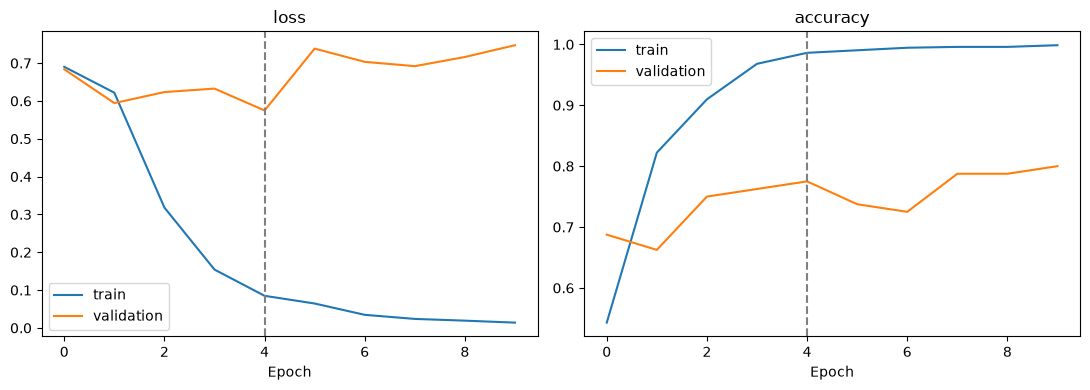

In [14]:
tf.keras.utils.set_random_seed(SEED)
lstm = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(vectorizer.vocabulary_size(), 96, mask_zero=True),  # mask_zero: bỏ qua phần đệm
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(1, activation="sigmoid"),
])
lstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
hist_lstm = lstm.fit(seq_tr, yr_tr, epochs=30, batch_size=32, validation_data=(seq_val, yr_val), verbose=0,
                     callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)])
best_epoch = int(np.argmin(hist_lstm.history["val_loss"])) + 1
print(f"Epoch đã chạy: {len(hist_lstm.history['loss'])}/30 · epoch tốt nhất (val_loss): {best_epoch}")
print(pd.DataFrame(hist_lstm.history, index=range(1, len(hist_lstm.history["loss"]) + 1)).round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, key in zip(axes, ("loss", "accuracy")):
    ax.plot(hist_lstm.history[key], label="train"); ax.plot(hist_lstm.history[f"val_{key}"], label="validation")
    ax.axvline(best_epoch - 1, ls="--", color="gray"); ax.set(title=key, xlabel="Epoch"); ax.legend()
save_show("ex4_learning_curve.png")

**Nhận xét:** mô hình **overfit rất nhanh**. Train accuracy lên 0.986 ở epoch 5 trong khi validation accuracy chỉ 0.775. Sau epoch 5, train loss tiếp tục giảm (0.085 → 0.014) còn val_loss tăng lại (0.575 → 0.747). EarlyStopping dừng ở epoch 10 và khôi phục trọng số của epoch 5. Validation chỉ có 80 câu nên đường validation khá nhiễu.

In [15]:
yr_pred = (lstm.predict(seq_te, verbose=0) > 0.5).astype(int).ravel()
f1_lstm = f1_score(yr_te, yr_pred, average="macro")
cm_lstm = confusion_matrix(yr_te, yr_pred)
report = classification_report(yr_te, yr_pred, target_names=["0 (Negative)", "1 (Positive)"], zero_division=0)
print(f"F1-Score (macro): {f1_lstm:.4f}\nConfusion Matrix [[TN, FP], [FN, TP]]:\n{cm_lstm}\n\n{report}")
write_report("ex4_lstm_sentiment_report.md",
             f"# Bài 4 – Bi-LSTM Sentiment Classification\n\n- Train / Validation / Test: {len(Xr_tr)} / {len(Xr_val)} / {len(Xr_te)}\n"
             f"- Seed: {SEED} · Epoch đã chạy: {len(hist_lstm.history['loss'])}/30 · Epoch tốt nhất: {best_epoch}\n"
             f"- **F1-Score (Macro): {f1_lstm:.4f}**\n\n## Confusion Matrix [[TN, FP], [FN, TP]]\n\n```\n{cm_lstm}\n```\n\n"
             f"## Classification Report\n\n```\n{report}```\n")

F1-Score (macro): 0.8499
Confusion Matrix [[TN, FP], [FN, TP]]:
[[87 13]
 [17 83]]

              precision    recall  f1-score   support

0 (Negative)       0.84      0.87      0.85       100
1 (Positive)       0.86      0.83      0.85       100

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.85      0.85      0.85       200

Đã lưu outputs/ex4_lstm_sentiment_report.md


**Nhận xét:** F1 macro **0.8499**. Hai lớp được nhận diện khá cân bằng (recall 0.87 / 0.83). Mô hình hơi thiên về đoán "tiêu cực": 17 câu tích cực bị đoán sai thành tiêu cực, so với 13 câu theo chiều ngược lại.

---
## Tổng kết

In [16]:
pd.DataFrame({
    "Bài": ["1. Wine clustering", "2. ANN regression", "3. MLP classification", "4. Bi-LSTM sentiment"],
    "Chỉ số": ["Silhouette (K = 3)", "RMSE (test)", "F1 weighted (test)", "F1 macro (test)"],
    "Kết quả": [f"{wine_score:.4f}", f"{np.sqrt(mse_ann):,.2f}", f"{f1_bean:.4f}", f"{f1_lstm:.4f}"],
}).set_index("Bài")

,Chỉ số,Kết quả
Bài,,
1. Wine clustering,Silhouette (K = 3),0.2849
2. ANN regression,RMSE (test),"12,854.74"
3. MLP classification,F1 weighted (test),0.9019
4. Bi-LSTM sentiment,F1 macro (test),0.8499
